# Etna Dataset Construction

This notebook builds the Etna case-study dataset for the Cause–Trigger analysis. Waveform features are extracted on an hourly grid, then merged with gas and meteorological context variables. The final dataset is used later for HMML/PCMCI-based trigger analysis.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from obspy.clients.fdsn import Client

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src/etna"
sys.path.append(str(SRC_DIR))

from etna_config import (
    ETNA_WAVEFORM_CONFIG,
    ETNA_GAS_METEO_COLS,
    ETNA_EVENT_TIME,
    ETNA_WEATHER_COLS,
)

from etna_waveform import build_station_waveform_dataset

from etna_dataset import (
    load_etnagas_csv,
    extract_plume_co2so2_xls,
    create_etna_final_dataset,
    load_openmeteo_etna_weather,
)

from etna_plotting_utils import (
    dataset_health_report,
    plot_scaled_dataset,
    plot_variable_pdfs,
    distribution_summary,
    run_teleseismic_checks,
    plot_etna_data_with_event,
)

client = Client("INGV")
cfg = ETNA_WAVEFORM_CONFIG

## 1. Station and channel metadata

We first inspect the available INGV metadata for the Etna stations. The vertical `EHZ` channel is used for waveform feature extraction because the trigger/response features are based on vertical ground motion.

In [2]:
# identify the station metadata for ME01/ME02, get the exact vertical channel
inventory = client.get_stations(station="ME01" # or "ME02"
                                ,level="response",
                                starttime = "2008-04-12 00:00:00.000",endtime = "2008-05-13 00:00:00.000")
print(inventory)

Inventory created at 2026-05-18T12:25:34.156000Z
	Created by: INGV-ONT WEB SERVICE: fdsnws-station | version: 1.1.64
		    /exist/apps/fdsn-station/fdsnws/station/1/query?starttime=2008-04-...
	Sending institution: eXistDB (INGV-ONT)
	Contains:
		Networks (1):
			IV
		Stations (1):
			IV.ME01 (Mistretta)
		Channels (3):
			IV.ME01..EHZ, IV.ME01..EHN, IV.ME01..EHE


In [3]:
network = inventory[0]
station = network[0] 
num_channels = len(station)
print ('number of channels: ', num_channels)
print(station)

number of channels:  3
Station ME01 (Mistretta)
	Station Code: ME01
	Channel Count: 3/3 (Selected/Total)
	2007-10-18T00:00:00.000000Z - 2009-02-03T23:00:00.000000Z
	Access: open 
	Latitude: 37.9329, Longitude: 14.3611, Elevation: 944.0 m
	Available Channels:
	    ..EH[ZNE]   125.0 Hz  2007-10-18 to 2009-02-03



In [4]:
channel = [c for c in station if c.code == "EHZ"][0]
print(channel)

Channel 'EHZ', Location '' 
	Time range: 2007-10-18T00:00:00.000000Z - 2009-02-03T23:00:00.000000Z
	Latitude: 37.9329, Longitude: 14.3611, Elevation: 944.0 m, Local Depth: 0.0 m
	Azimuth: 0.00 degrees from north, clockwise
	Dip: -90.00 degrees down from horizontal
	Sampling Rate: 125.00 Hz
	Sensor (Description): None (LENNARTZ LE3D-5S)
	Response information available


## 2. Hourly waveform feature extraction

For each station, waveform data are processed in daily chunks with padding for filter stability. Three log-transformed RMS features are extracted:

- `teleseismic_band`: low-frequency teleseismic trigger band, aggregated by hourly maximum.
- `background_seismic`: background/state band, aggregated by hourly mean.
- `effect_seismic`: high-frequency response band, aggregated by hourly maximum.

In [5]:
REDOWNLOAD = False # set to True to force redownloading and reprocessing of the waveform data, which is time consuming. Set to False to load from the cached pickle files.

me01_wave, me01_failures = build_station_waveform_dataset(
    client=client,
    station="ME01",
    cfg=cfg,
    cache_path="../data_etna/etna_me01_waveform.pkl",
    redownload=REDOWNLOAD,
)

me02_wave, me02_failures = build_station_waveform_dataset(
    client=client,
    station="ME02",
    cfg=cfg,
    cache_path="../data_etna/etna_me02_waveform.pkl",
    redownload=REDOWNLOAD,
)

ME01: loading cached waveform features from ..\data_etna\etna_me01_waveform.pkl
ME02: loading cached waveform features from ..\data_etna\etna_me02_waveform.pkl


## 3. Gas and meteorological variables

We add slower contextual variables from ETNAGAS and plume observations. These variables are merged onto the hourly waveform grid.

- WindSpeed  
- AirTemp_3 
- CO2_3 
- plume data (SO2/CO2 ratio)

pressure_drop is derived from Patm_3 in ETNAGAS dataset.

API is derived from Open-Meteo.

In [6]:
plume_df = extract_plume_co2so2_xls("../data_etna/1012-1_VolcanicGas_Etna.xls")

In [7]:
etnagas_df = load_etnagas_csv(
    path="../data_etna/3c.csv",
    value_cols=ETNA_GAS_METEO_COLS,
)

display(etnagas_df.head())
display(etnagas_df.isna().mean().sort_values())

,timestamp,CO2_3,AirTemp_3,pressure_drop,WindSpeed
0,2008-01-18 00:00:00+00:00,0.283836,NaN,0.0,0.0
1,2008-01-18 01:00:00+00:00,0.287348,NaN,0.0,0.0
2,2008-01-18 02:00:00+00:00,0.274303,NaN,0.0,0.0
3,2008-01-18 03:00:00+00:00,0.269285,NaN,0.0,0.0
4,2008-01-18 04:00:00+00:00,0.265773,NaN,0.0,0.0


timestamp        0.000000
pressure_drop    0.000000
WindSpeed        0.000039
CO2_3            0.002269
AirTemp_3        0.012401
dtype: float64

In [8]:
etna_weather_df = load_openmeteo_etna_weather(
    start_date="2008-04-12",
    end_date="2008-05-14",
)

## 4. Merge, scale, and save final hourly datasets

The waveform, gas, meteorological, and plume variables are merged by timestamp. Raw variables are retained, and scaled versions are produced for causal discovery. The output is saved separately for ME01 and ME02.

In [9]:
final_me01_raw, final_me01_scaled = create_etna_final_dataset(
    wave_df=me01_wave,
    station_name="ME01",
    out_csv="../data_etna/FINAL_ME01.csv",
    etnagas_df=etnagas_df,
    etnagas_cols=ETNA_GAS_METEO_COLS,
    plume_df=plume_df,
    weather_df=etna_weather_df,
    weather_cols=ETNA_WEATHER_COLS,
)

final_me02_raw, final_me02_scaled = create_etna_final_dataset(
    wave_df=me02_wave,
    station_name="ME02",
    out_csv="../data_etna/FINAL_ME02.csv",
    etnagas_df=etnagas_df,
    etnagas_cols=ETNA_GAS_METEO_COLS,
    plume_df=plume_df,
    weather_df=etna_weather_df,
    weather_cols=ETNA_WEATHER_COLS,
)

Saved: ../data_etna/FINAL_ME01_raw.csv
Saved: ../data_etna/FINAL_ME01_scaled.csv
Saved: ../data_etna/FINAL_ME02_raw.csv
Saved: ../data_etna/FINAL_ME02_scaled.csv


In [10]:
# load saved datasets for analysis
#final_me01_raw = pd.read_csv("../data_etna/FINAL_ME01_raw.csv", parse_dates=["timestamp"]).set_index("timestamp")
#final_me01_scaled = pd.read_csv("../data_etna/FINAL_ME01_scaled.csv", parse_dates=["timestamp"]).set_index("timestamp")
#final_me02_raw = pd.read_csv("../data_etna/FINAL_ME02_raw.csv", parse_dates=["timestamp"]).set_index("timestamp")
#final_me02_scaled = pd.read_csv("../data_etna/FINAL_ME02_scaled.csv", parse_dates=["timestamp"]).set_index("timestamp")

## 5. Dataset checks

We check dataset size, timestamp order, duplicate timestamps, missing values, and variable distributions. These checks ensure that the final hourly dataset is suitable for causal discovery.

In [11]:
station_data = {
    "ME01": {
        "wave": me01_wave,
        "final_raw": final_me01_raw,
        "final_scaled": final_me01_scaled,
    },
    "ME02": {
        "wave": me02_wave,
        "final_raw": final_me02_raw,
        "final_scaled": final_me02_scaled,
    },
}

In [12]:
for sta, d in station_data.items():
    dataset_health_report(d["final_raw"], f"{sta} hourly raw")
    dataset_health_report(d["final_scaled"], f"{sta} hourly scaled")


ME01 hourly raw
shape: (768, 11)
duplicate timestamps: 0
time sorted: True

Missing fraction:
station               0.0
time                  0.0
teleseismic_band      0.0
background_seismic    0.0
effect_seismic        0.0
CO2_3                 0.0
AirTemp_3             0.0
pressure_drop         0.0
WindSpeed             0.0
API                   0.0
CO2_SO2               0.0
dtype: float64

ME01 hourly scaled
shape: (768, 11)
duplicate timestamps: 0
time sorted: True

Missing fraction:
time                         0.0
station                      0.0
teleseismic_band_scaled      0.0
background_seismic_scaled    0.0
effect_seismic_scaled        0.0
CO2_3_scaled                 0.0
AirTemp_3_scaled             0.0
pressure_drop_scaled         0.0
WindSpeed_scaled             0.0
API_scaled                   0.0
CO2_SO2_scaled               0.0
dtype: float64

ME02 hourly raw
shape: (752, 11)
duplicate timestamps: 0
time sorted: True

Missing fraction:
station               0.0
time   

## 6. Time-series inspection

The scaled variables are plotted to inspect temporal structure, outliers, and station-level differences. This helps identify whether the extracted variables behave consistently across ME01 and ME02.

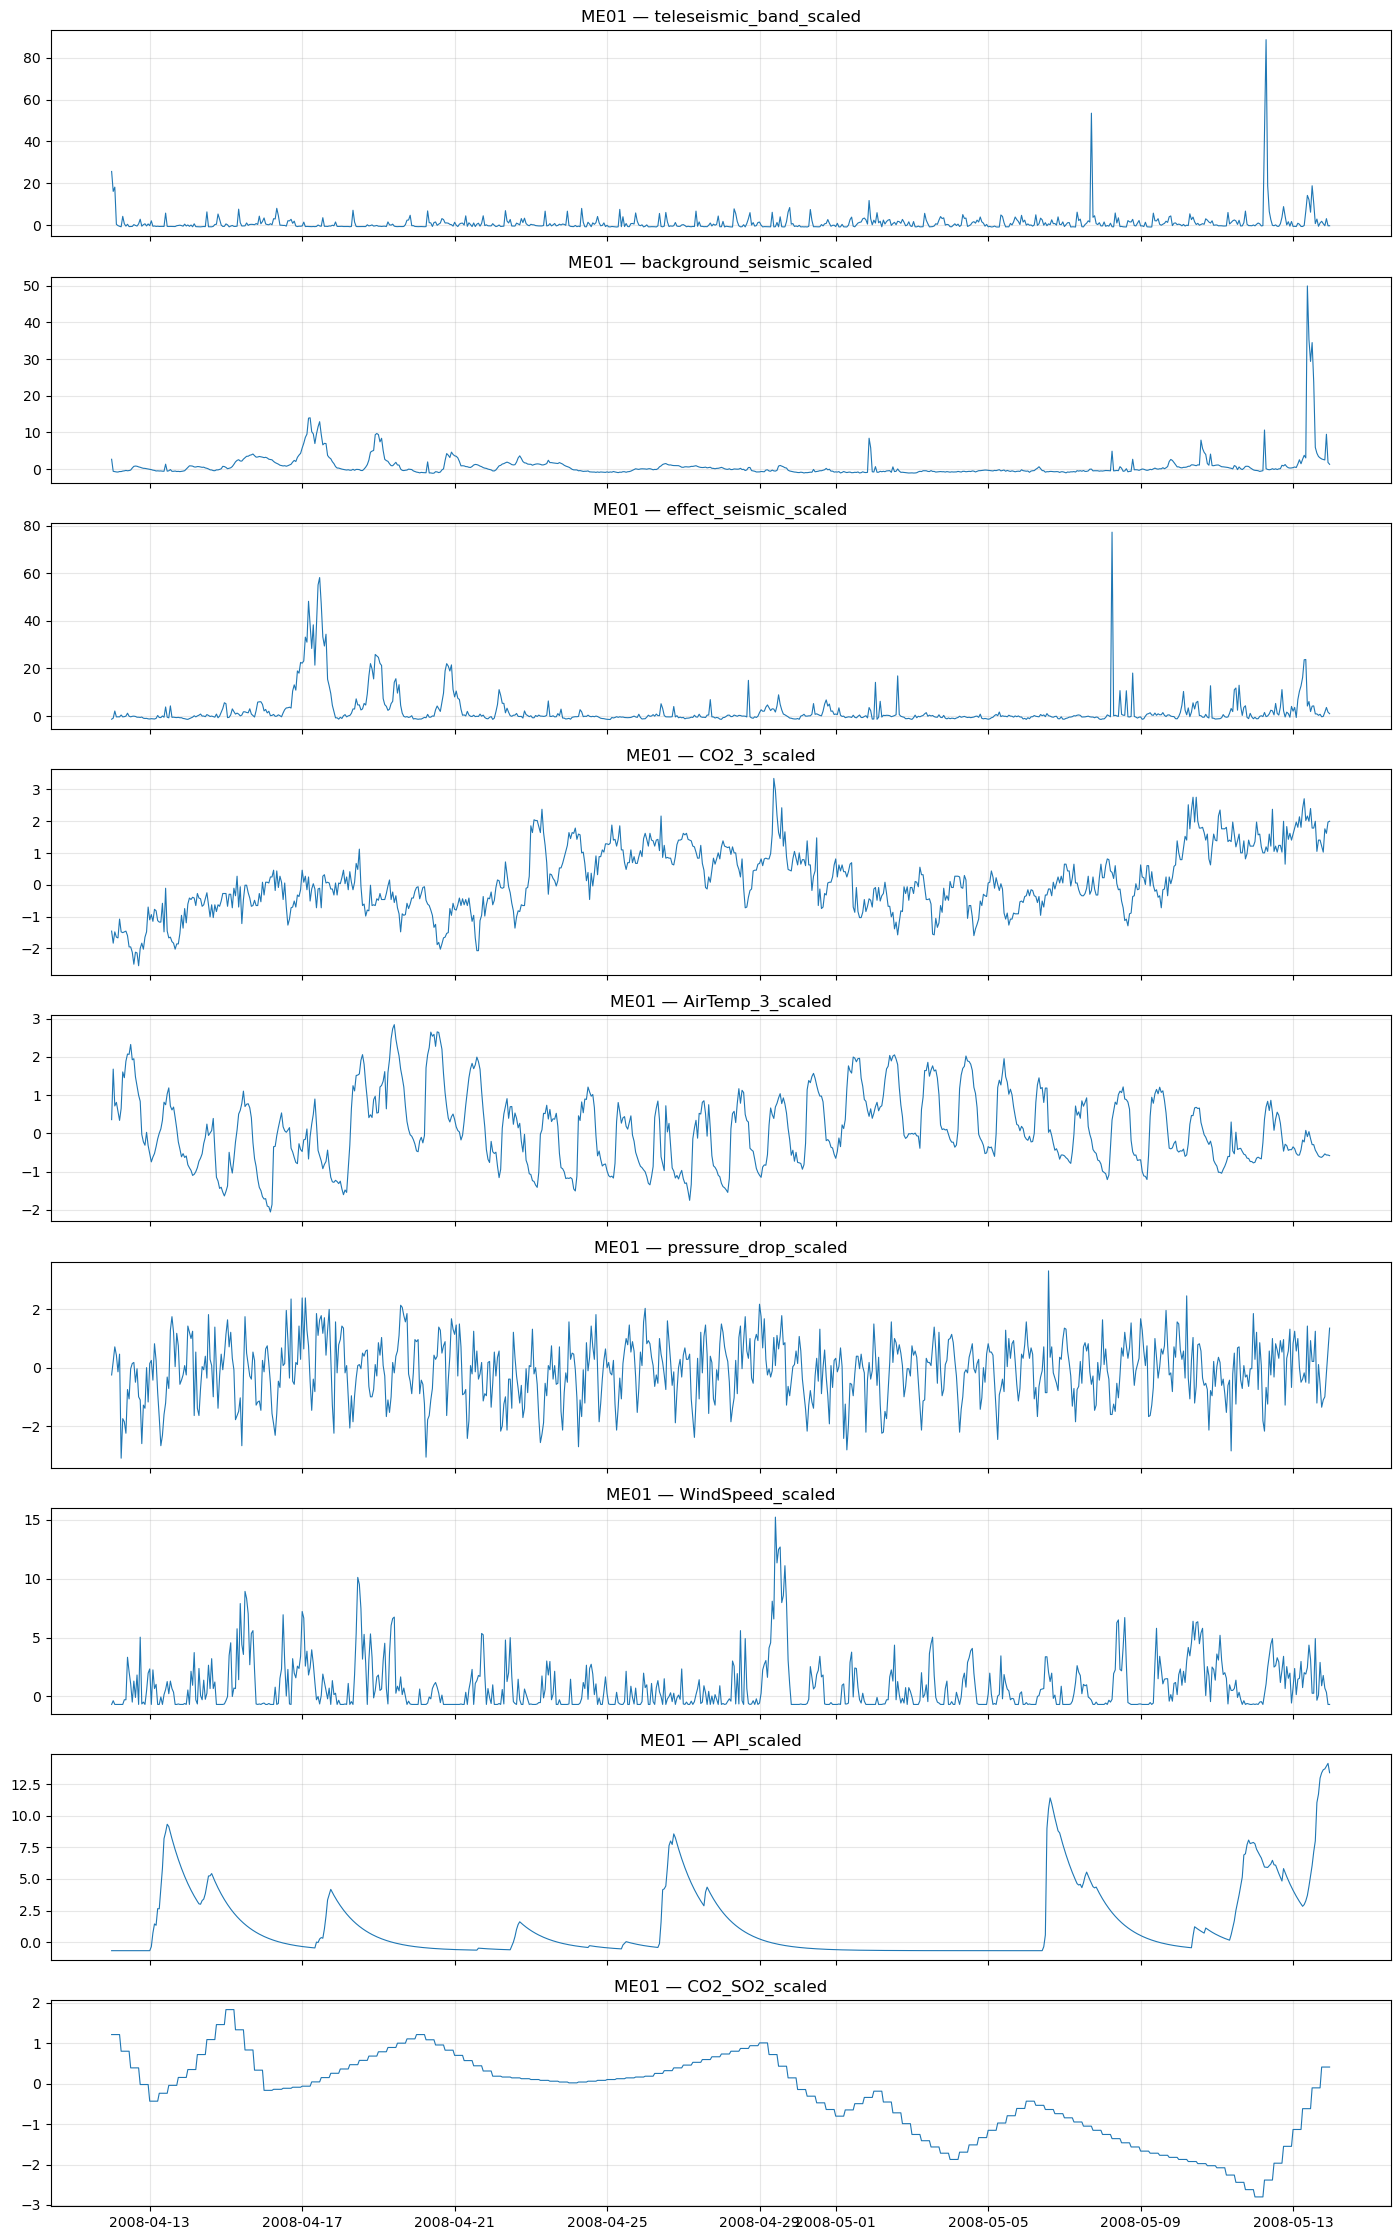

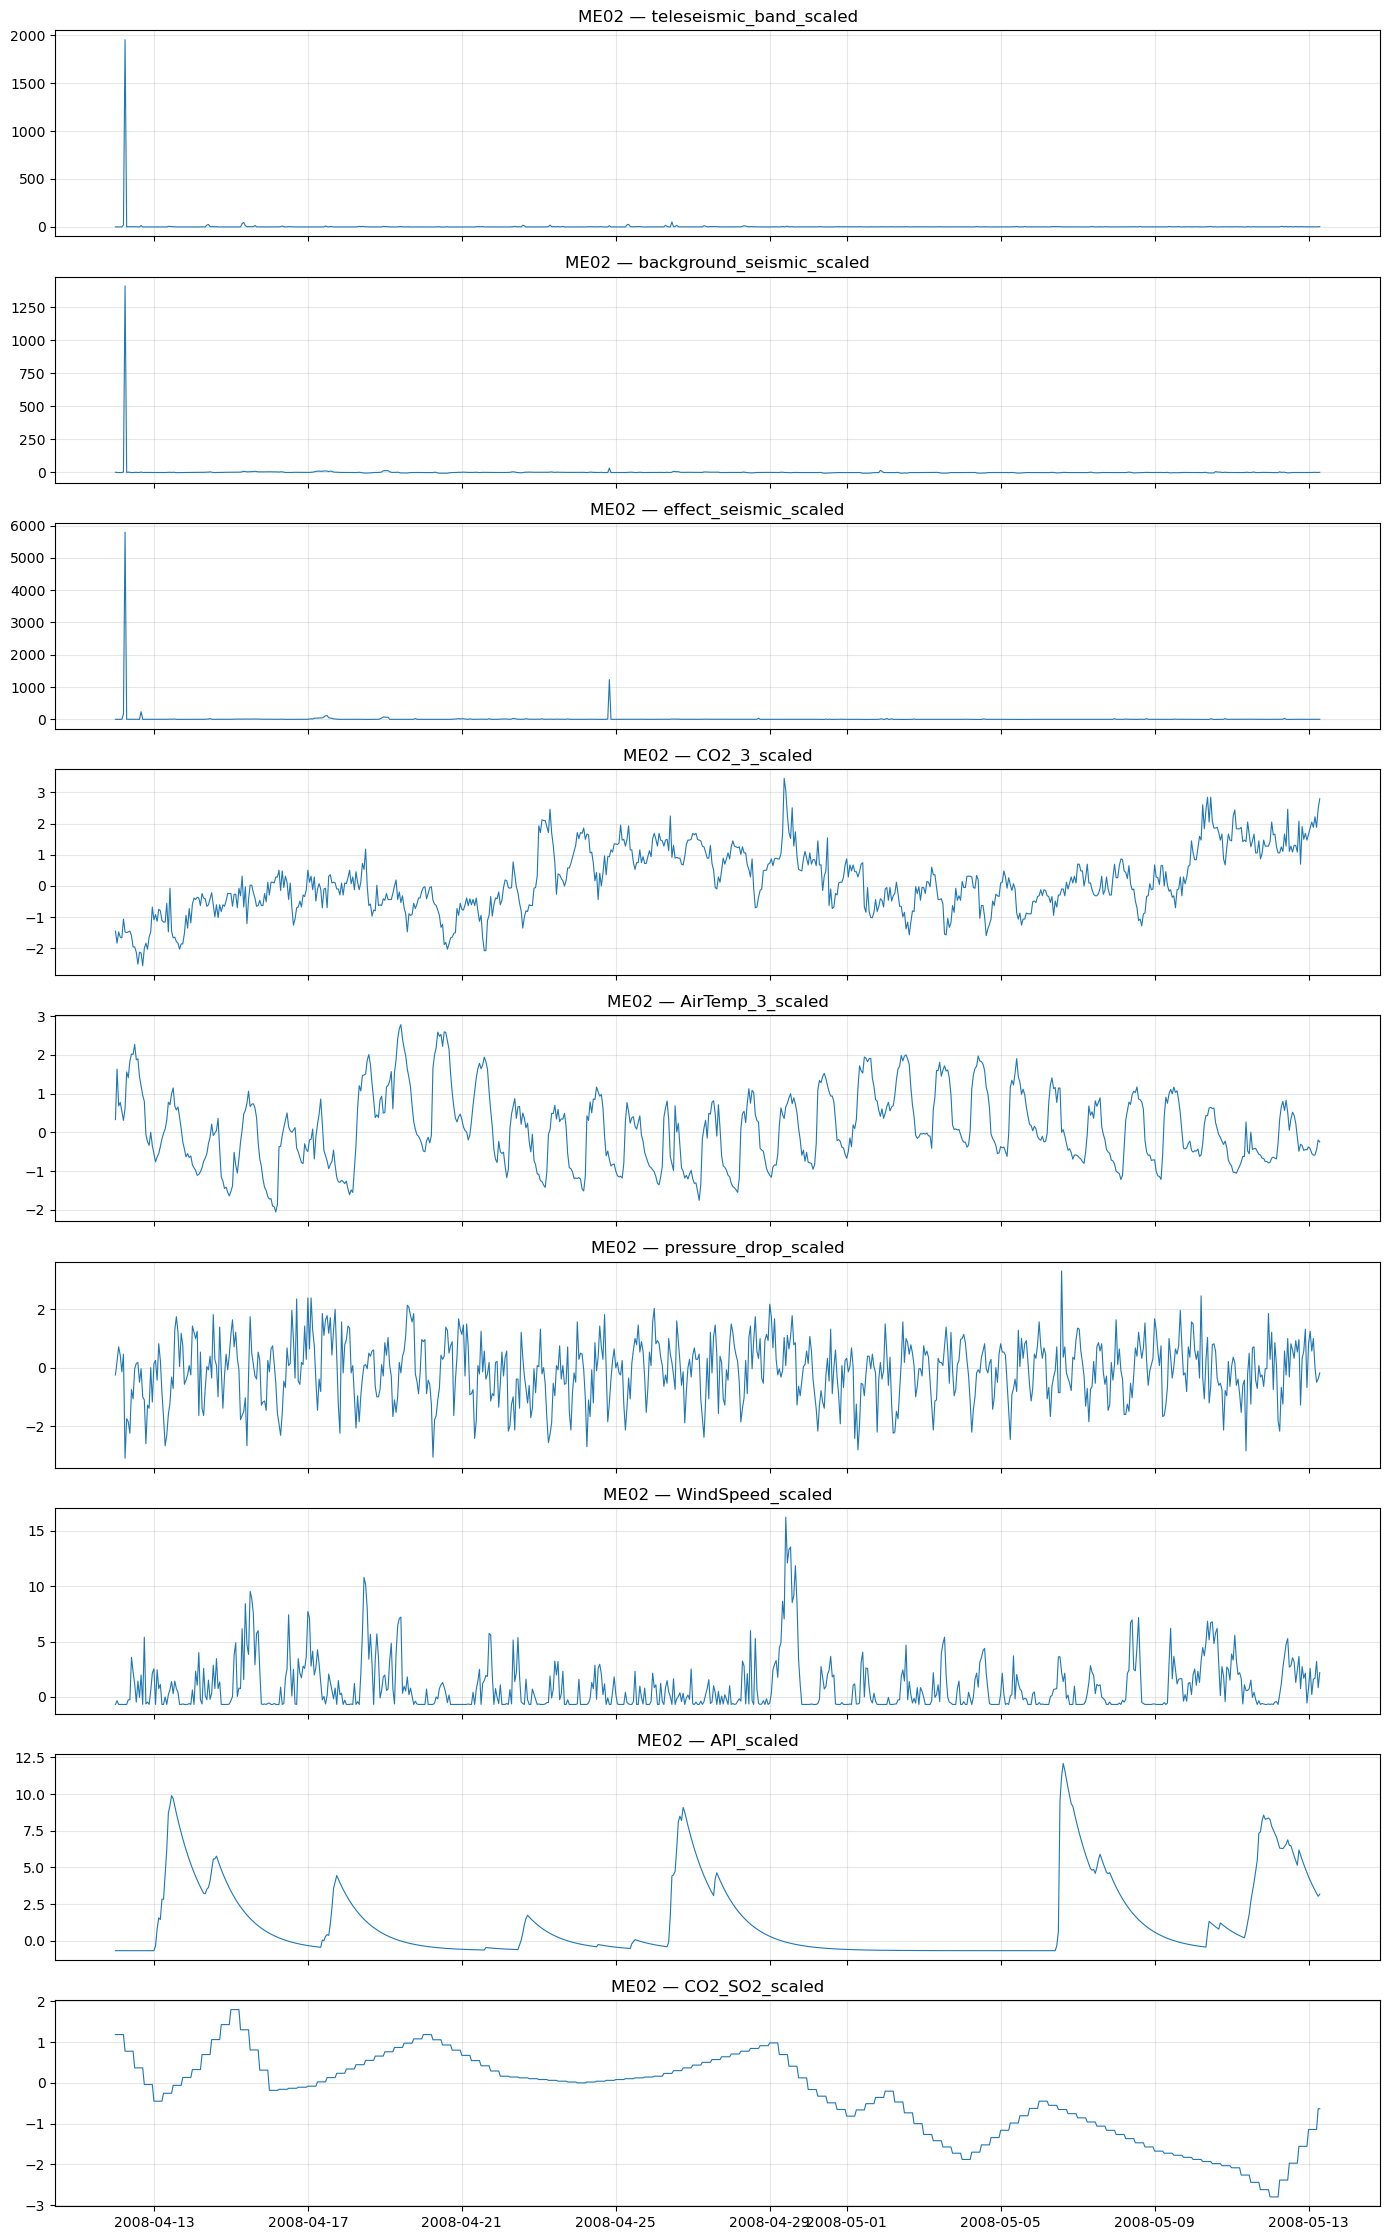

In [13]:
for sta, d in station_data.items():
    plot_scaled_dataset(d["final_scaled"], sta)

## 7. Distribution diagnostics

Empirical density plots and summary statistics are used to inspect skewness, outliers, and scaling behavior. 

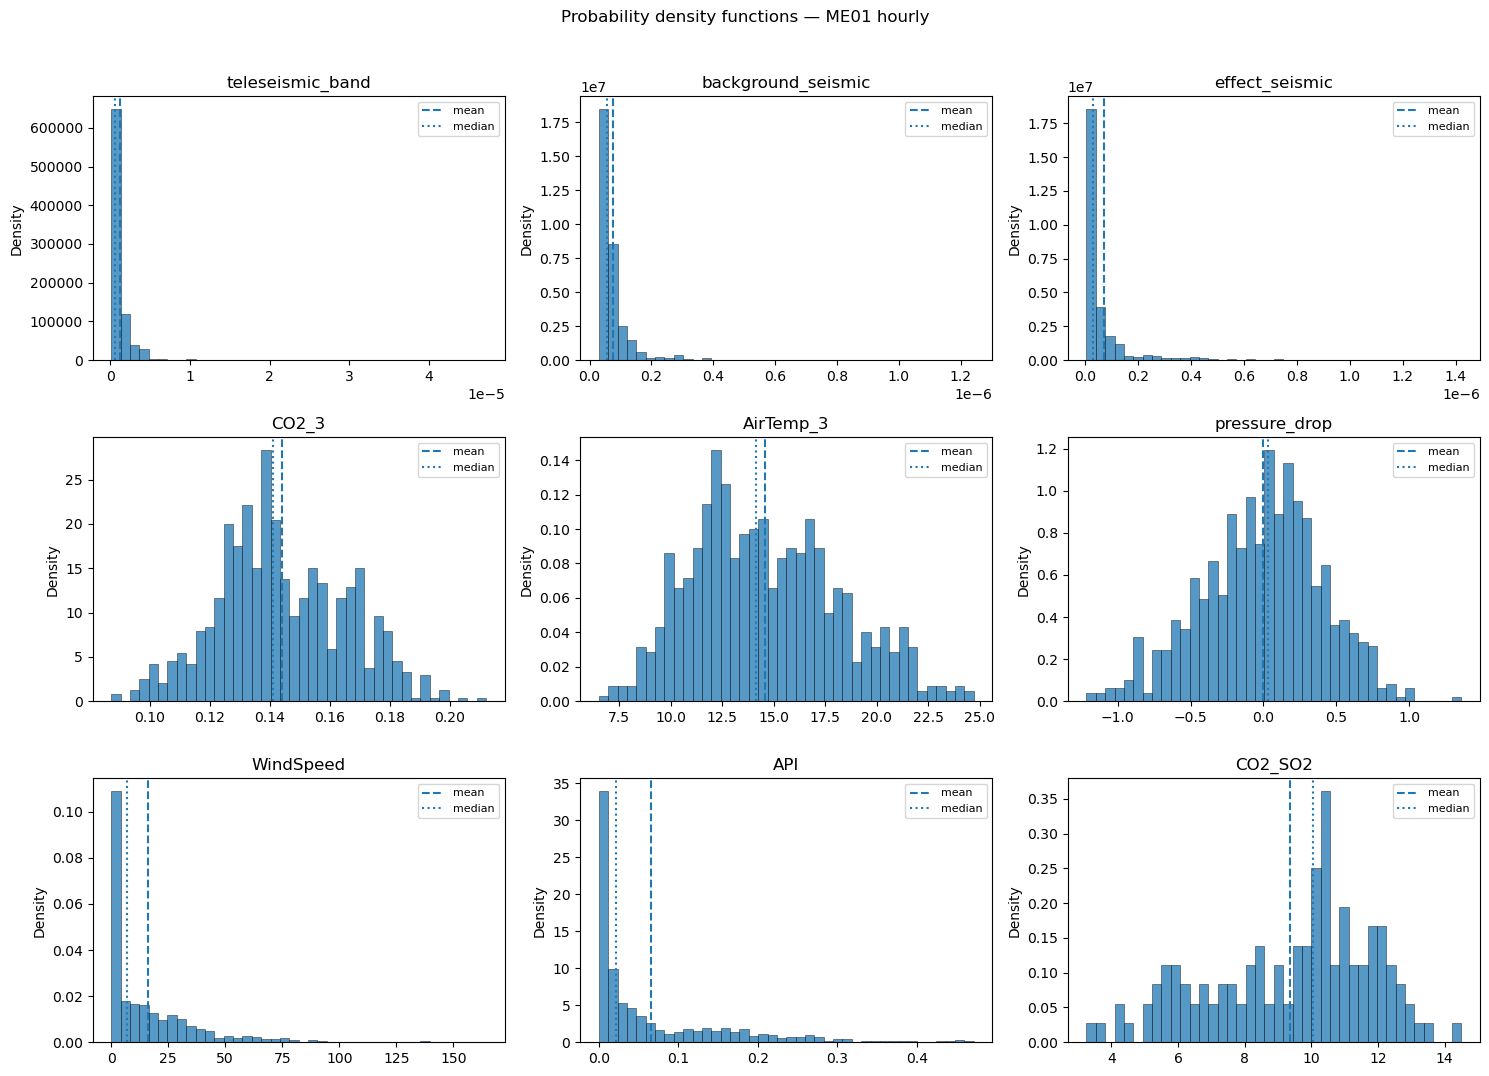

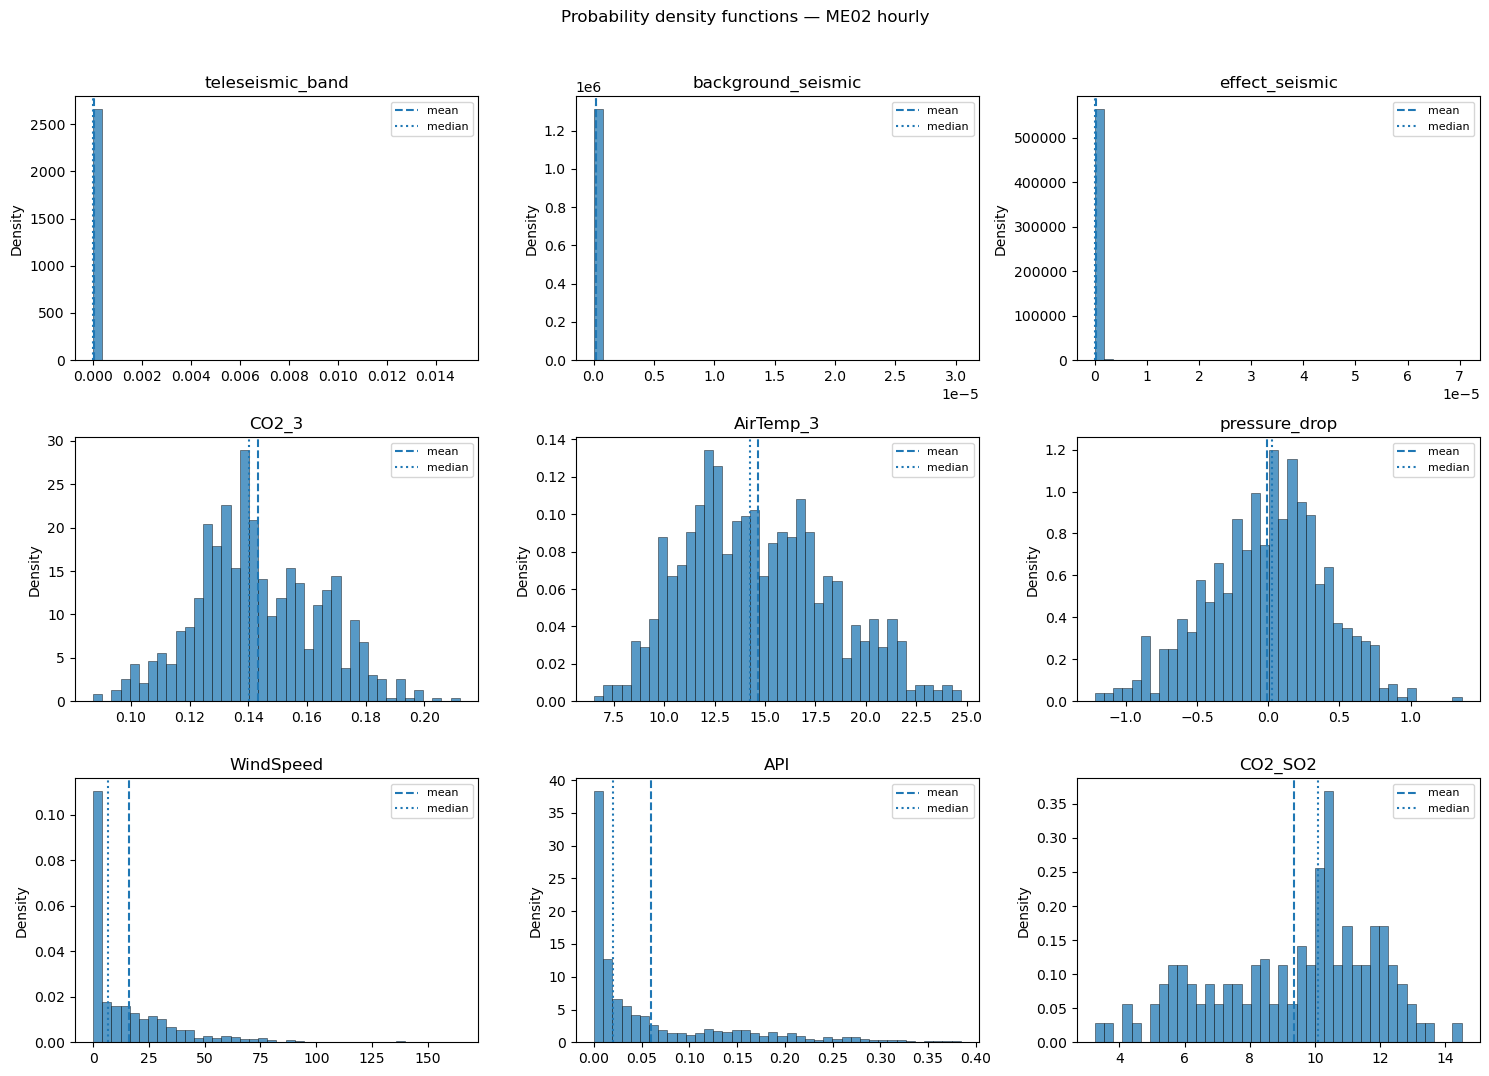

In [14]:
plot_variable_pdfs(final_me01_raw, "ME01 hourly")
plot_variable_pdfs(final_me02_raw, "ME02 hourly")

#### distribution summary table

In [15]:
summary_me01 = distribution_summary(final_me01_raw, "ME01 hourly")
summary_me02 = distribution_summary(final_me02_raw, "ME02 hourly")

display(summary_me01)
display(summary_me02)

ME01 hourly
ME02 hourly


,count,mean,std,min,median,max,skew,n_unique,missing_fraction
API,768.0,6.574766e-02,9.062734e-02,0.000000e+00,2.152954e-02,0.471235,1.813461,744,0.0
AirTemp_3,768.0,1.458406e+01,3.554884e+00,6.505817e+00,1.413981e+01,24.711043,0.385937,653,0.0
CO2_3,768.0,1.440061e-01,2.148863e-02,8.714800e-02,1.410860e-01,0.212085,0.180726,164,0.0
CO2_SO2,768.0,9.366797e+00,2.453493e+00,3.250000e+00,1.005000e+01,14.500000,-0.475693,108,0.0
WindSpeed,768.0,1.604071e+01,2.236661e+01,0.000000e+00,6.967213e+00,164.344262,2.271767,161,0.0
background_seismic,768.0,7.669476e-08,8.274277e-08,2.977942e-08,5.624599e-08,0.000001,0.000000,768,0.0
effect_seismic,768.0,7.364931e-08,1.307731e-07,5.895401e-09,3.149237e-08,0.000001,0.000000,768,0.0
pressure_drop,768.0,-5.308418e-03,4.113819e-01,-1.215906e+00,2.861000e-02,1.358955,-0.211724,284,0.0
teleseismic_band,768.0,1.165822e-06,2.479898e-06,1.326138e-07,5.933737e-07,0.000047,11.622191,768,0.0


,count,mean,std,min,median,max,skew,n_unique,missing_fraction
API,752.0,6.010109e-02,0.080652,0.000000e+00,2.037367e-02,0.384294,1.574795,728,0.0
AirTemp_3,752.0,1.462461e+01,3.579205,6.505817e+00,1.424709e+01,24.711043,0.357167,643,0.0
CO2_3,752.0,1.432889e-01,0.021105,8.714800e-02,1.403340e-01,0.212085,0.194766,164,0.0
CO2_SO2,752.0,9.354255e+00,2.473870,3.250000e+00,1.010000e+01,14.500000,-0.461072,106,0.0
WindSpeed,752.0,1.592475e+01,22.445446,0.000000e+00,6.557377e+00,164.344262,2.295303,161,0.0
background_seismic,752.0,2.108531e-07,0.000001,3.869875e-08,1.625881e-07,0.000030,27.289448,752,0.0
effect_seismic,752.0,2.210671e-07,0.000003,1.095271e-08,7.111369e-08,0.000070,25.741956,752,0.0
pressure_drop,752.0,-5.820831e-03,0.412330,-1.215906e+00,2.861000e-02,1.358955,-0.216658,279,0.0
teleseismic_band,752.0,4.760316e-05,0.000547,8.692512e-06,2.119410e-05,0.014994,27.299051,752,0.0


## 8. Teleseismic arrival diagnostics

We inspect the waveform around the Wenchuan earthquake arrival. The 1-minute RMS is compared with hourly maximum aggregation to verify that the hourly grid preserves the arrival-period energy. The spectrogram confirms that the selected frequency bands capture the relevant trigger and response components.

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\obspy\core\inventory\response.py:988: UserWarning: Input sampling rate of stage 3 is inconsistent with the previous stages' output sampling rate
  warnings.warn(msg % i)


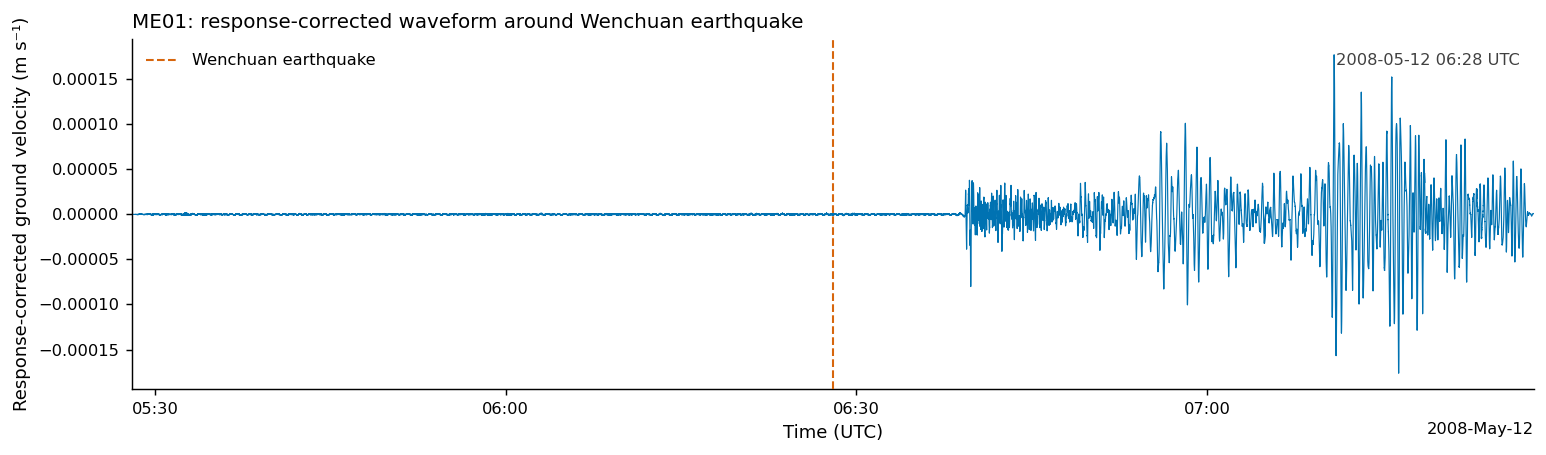

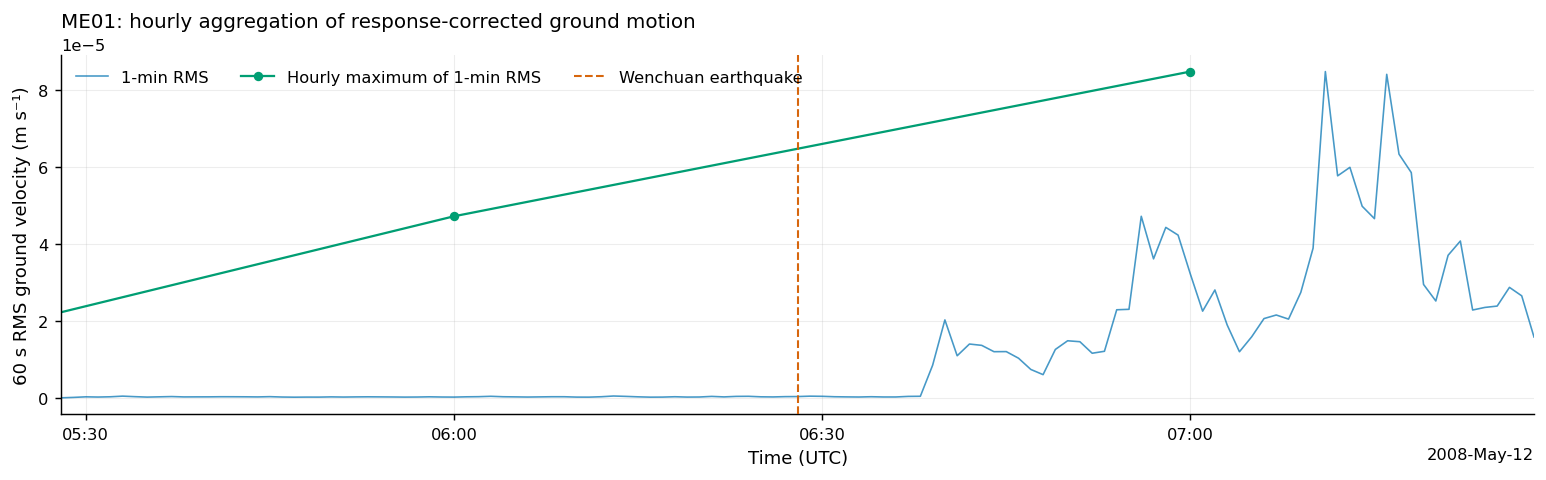


ME01
1-min peak: 2008-05-12 07:11:00+00:00
hourly peak bin: 2008-05-12 07:00:00+00:00
difference: 0 days 00:11:00


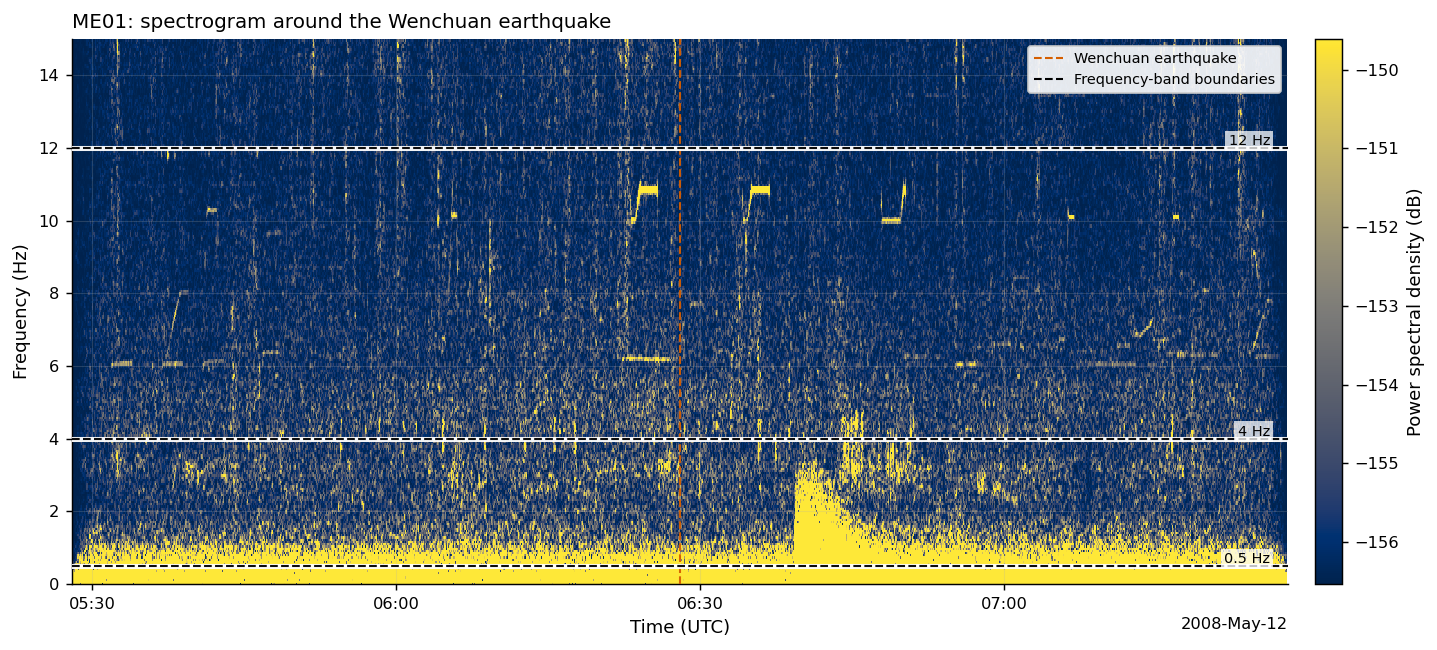

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\obspy\core\inventory\response.py:988: UserWarning: Input sampling rate of stage 3 is inconsistent with the previous stages' output sampling rate
  warnings.warn(msg % i)


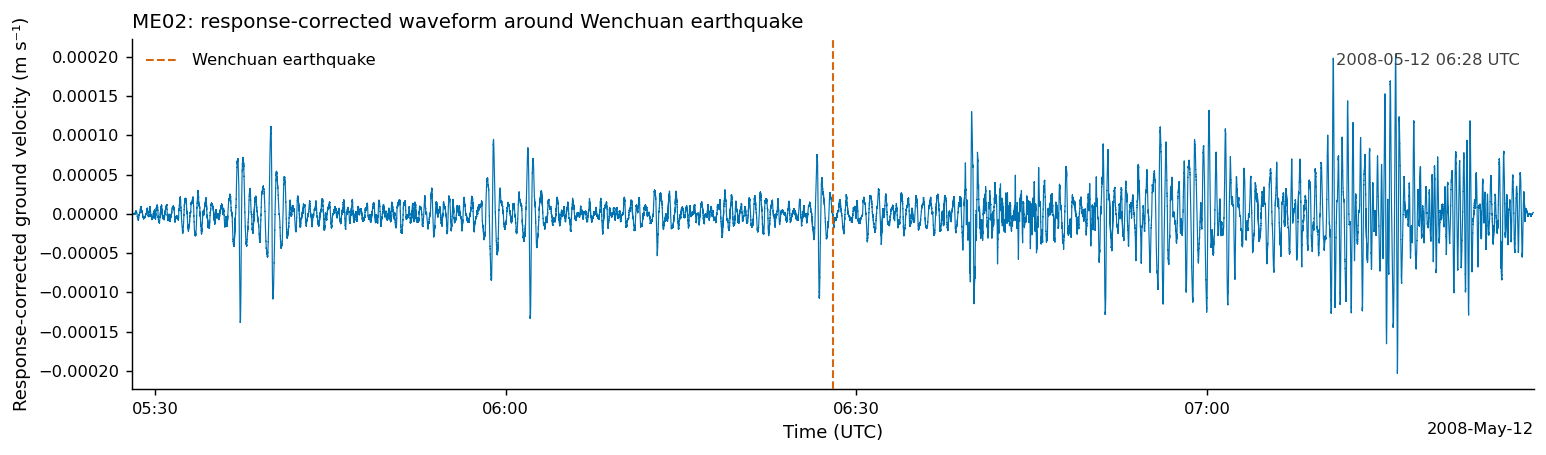

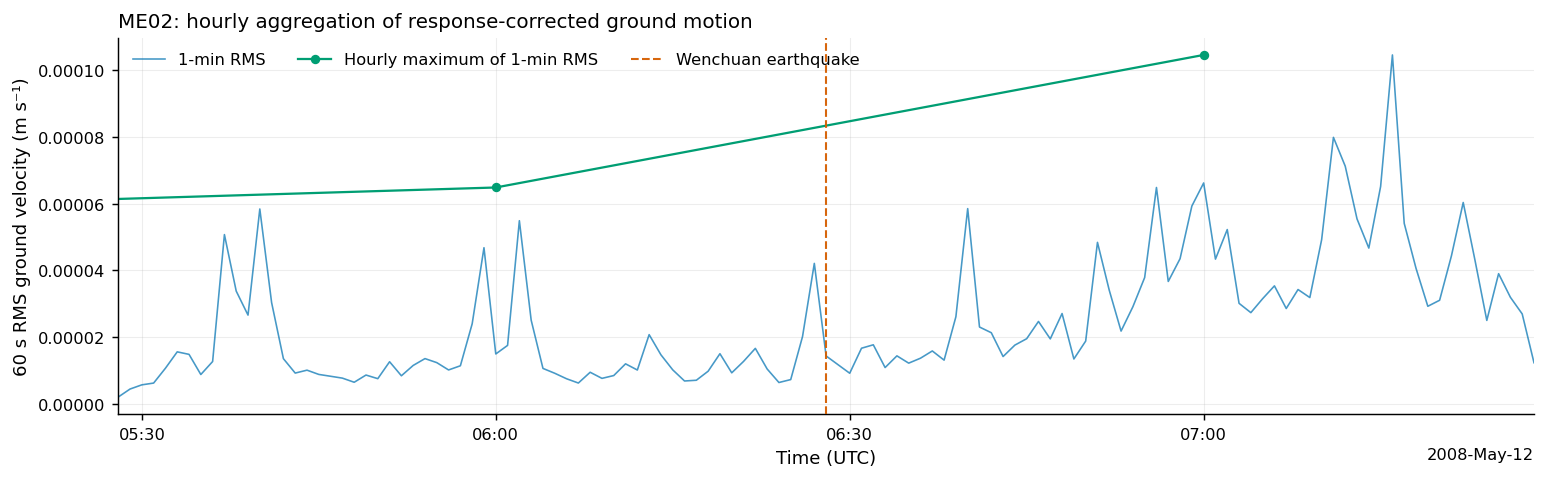


ME02
1-min peak: 2008-05-12 07:16:00+00:00
hourly peak bin: 2008-05-12 07:00:00+00:00
difference: 0 days 00:16:00


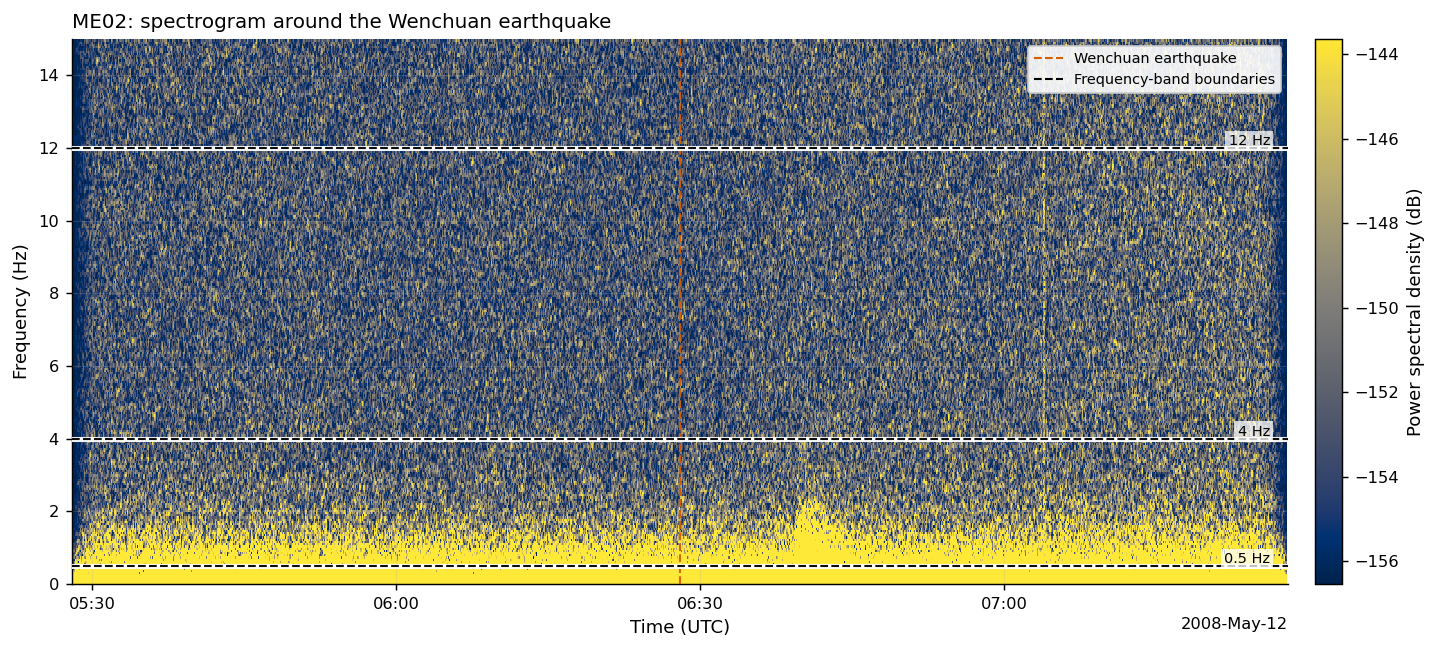

In [16]:
results = {}

for station in ["ME01", "ME02"]:
    results[station] = run_teleseismic_checks(
        client=client,
        station=station,
        cfg=ETNA_WAVEFORM_CONFIG,
        event_time=ETNA_EVENT_TIME,
    )

## 9. Final hourly dataset with event marker

The final dataset is plotted with the teleseismic event time marked. This provides a visual check that the causal-analysis dataset aligns with the known event window.

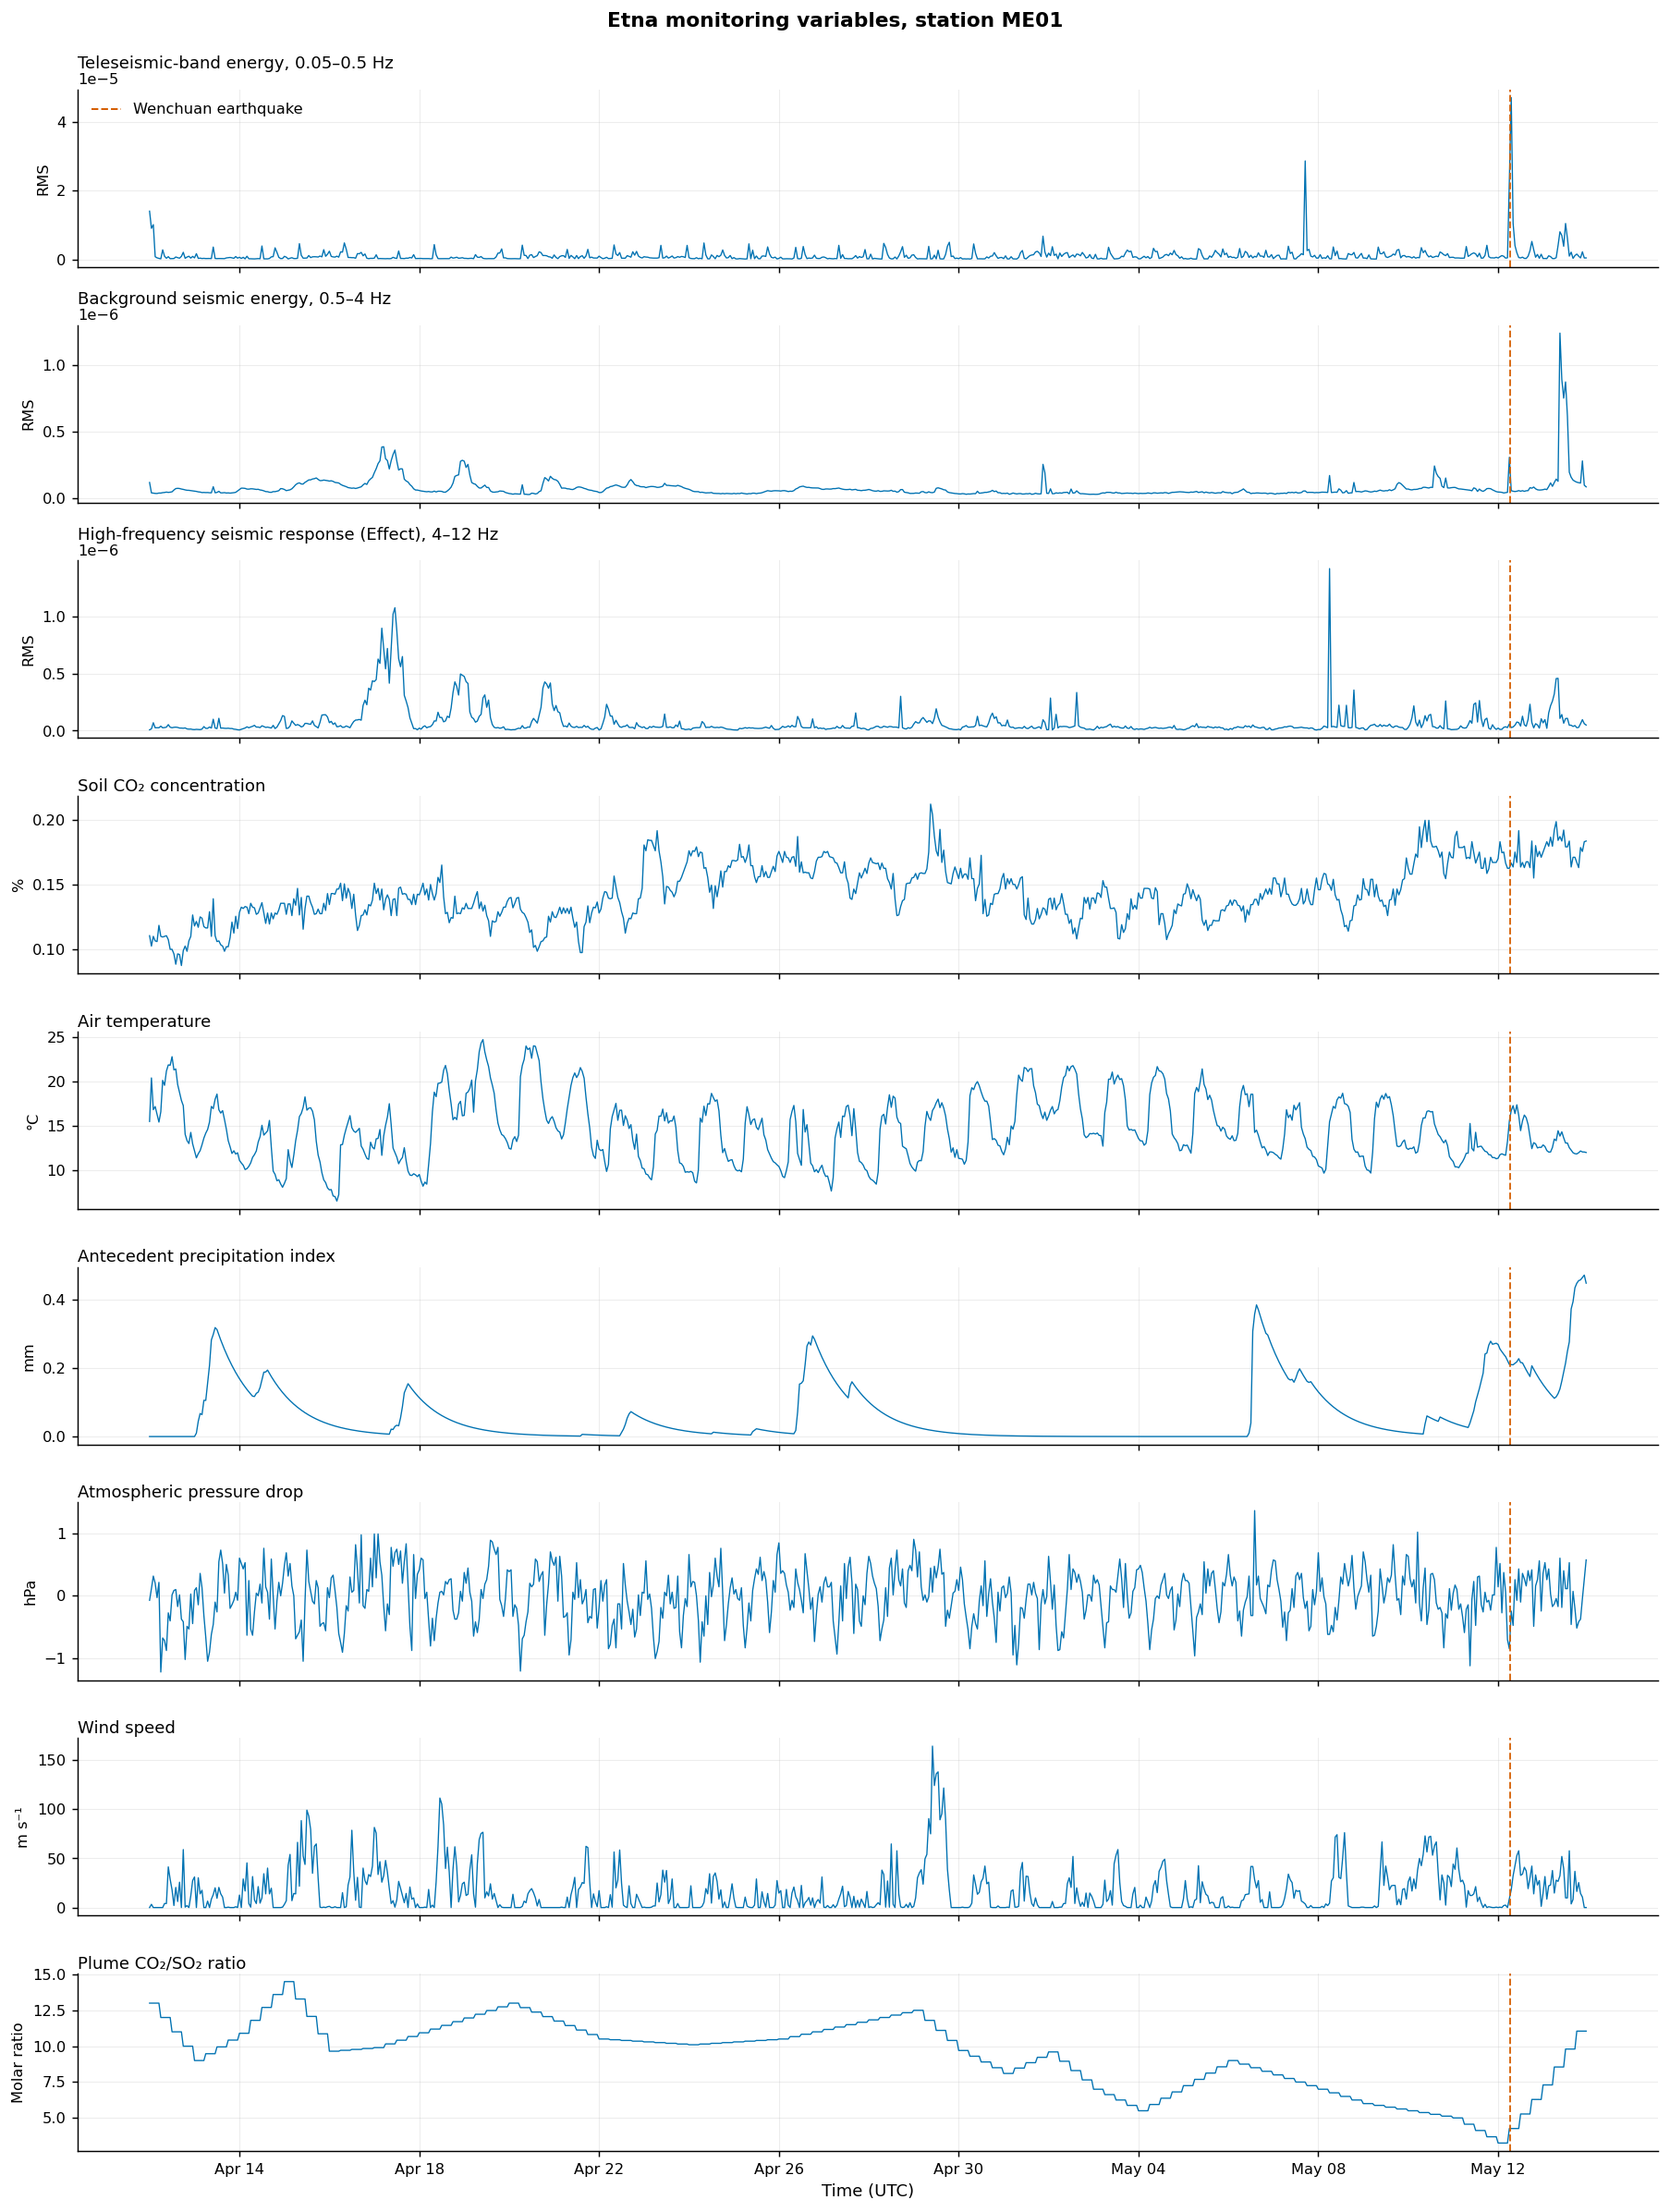

In [17]:
plot_etna_data_with_event(
    "../data_etna/FINAL_ME01_raw.csv",
    station="ME01",
    event_time=ETNA_EVENT_TIME,
    title="Etna monitoring variables, station ME01",
)